In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os

%matplotlib inline
sns.set(style='whitegrid')

current_dir = os.getcwd()
base_dir = os.path.dirname(current_dir)
train_path = os.path.join(base_dir, 'data', 'preprocessed', 'train_data.csv')
test_path = os.path.join(base_dir, 'data', 'preprocessed', 'test_data.csv')

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Dữ liệu huấn luyện: {train_df.shape}")
print(f"Dữ liệu kiểm tra: {test_df.shape}")

Dữ liệu huấn luyện: (7292, 14)
Dữ liệu kiểm tra: (1824, 14)




## 2. Feature Engineering & Khử nhiễu thông minh
Mô hình OLS cực kỳ nhạy cảm với Outliers. Tại bước này, tôi thực hiện thiết kế đặc trưng đa tầng:

*   **Khử nhiễu mật độ (Gaussian KDE):** Sử dụng thuật toán *Kernel Density Estimation* để xác định mật độ phân phối của giá. Tôi tiến hành loại bỏ các bất động sản có giá trị cực cao (> 80 tỷ) nhưng lại đứng cô lập (nằm trong nhóm 5% mật độ thấp nhất). Việc này giúp loại bỏ "nhiễu" từ các tin đăng ảo, giúp đường hồi quy tập trung vào dải dữ liệu thực tế.
*   **Đặc trưng đa thức (Non-linear Area):** Thêm biến diện tích bình phương (`dien_tich_log_sq`) để mô hình hóa quan hệ phi tuyến giữa diện tích và giá trị, giúp mô hình bắt được quy luật thay đổi giá theo đường cong.



In [33]:
from scipy.stats import gaussian_kde

def feature_engineering_m5_optimized(df, is_train=True):
    df_fe = df.copy()
    
    # 1. KHỬ NHIỄU MẬT ĐỘ (KDE) - Giữ lại vì đây là phần hay của model này
    if is_train:
        prices = df_fe['gia'].values
        kde = gaussian_kde(prices)
        df_fe['price_density'] = kde(prices)
        density_threshold = df_fe['price_density'].quantile(0.05)
        # Loại bỏ các điểm có giá quá cao nhưng mật độ xuất hiện cực thấp
        noise_mask = (df_fe['gia'] > 80) & (df_fe['price_density'] < density_threshold)
        df_fe = df_fe[~noise_mask].copy()
    
    # 2. DIỆN TÍCH ĐA THỨC (Bắt đường cong giá)
    df_fe['dien_tich_log_sq'] = df_fe['dien_tich_log'] ** 2

    return df_fe

# Chạy hàm FE
train_fe = feature_engineering_m5_optimized(train_df, is_train=True)
test_fe = feature_engineering_m5_optimized(test_df, is_train=False)



## 3. Chuẩn bị dữ liệu, Mã hóa One-Hot & Tương tác không gian
Đây là bước tiền xử lý quan trọng nhất để tối ưu hóa sức mạnh của mô hình tuyến tính:

*   **Mã hóa One-Hot (Dummy Variables):** Chuyển đổi các biến định danh `quan` (Quận) và `phap_ly` (Pháp lý) thành các cột nhị phân (0 và 1). Việc này giúp thuật toán OLS có thể xử lý được các biến hạng mục.
*   **Biến Tương tác không gian (Spatial Interaction):** Sau khi mã hóa One-Hot, tôi thực hiện nhân diện tích (`dien_tich_log`) với từng cột `Quận` đã mã hóa. Kỹ thuật này tạo ra một "đơn giá biên" riêng biệt cho mỗi khu vực, giải thích lý do tại sao cùng một diện tích nhưng giá ở Quận 1 lại khác biệt so với Quận 12.
*   **Đồng bộ hóa tập dữ liệu:** Sử dụng hàm `reindex` để đảm bảo tập Kiểm tra có cấu trúc cột hoàn toàn trùng khớp với tập Huấn luyện, giúp dự báo ổn định và tránh lỗi ma trận.



In [34]:
# Danh sách cột (Bỏ is_facade)
features_to_keep = ['dien_tich_log', 'dien_tich_log_sq', 'phong_tam', 'so_tang', 'quan', 'phap_ly']

# 1. Tách X và y
X_train_raw = train_fe[features_to_keep]
y_train = train_fe['gia_log']
X_test_raw = test_fe[features_to_keep]
y_test_original = test_df['gia']

# 2. Mã hóa One-Hot
X_train = pd.get_dummies(X_train_raw, columns=['quan', 'phap_ly'], drop_first=True)
X_test = pd.get_dummies(X_test_raw, columns=['quan', 'phap_ly'], drop_first=True)

# 3. TƯƠNG TÁC KHÔNG GIAN (Diện tích * Quận)
district_cols = [col for col in X_train.columns if 'quan_' in col]
for col in district_cols:
    X_train[f'inter_{col}'] = X_train['dien_tich_log'] * X_train[col]
    X_test[f'inter_{col}'] = X_test['dien_tich_log'] * X_test[col]

# Đồng bộ hóa cột
X_test = X_test.reindex(columns = X_train.columns, fill_value=0)


# 4. Huấn luyện mô hình Linear Regression
Sử dụng thuật toán Hồi quy tuyến tính OLS (Ordinary Least Squares). Với bộ đặc trưng đã được làm sạch và mở rộng lên khoảng 40-70 biến, mô hình giờ đây không chỉ là một phương trình đơn giản mà là một hệ thống các hệ số có khả năng bắt lấy sự biến động tinh vi của thị trường bất động sản theo từng phân khúc và khu vực.



In [35]:
# Khởi tạo và Huấn luyện OLS truyền thống
model = LinearRegression()
model.fit(X_train, y_train)

print(f"--- MODEL 4: HUẤN LUYỆN HOÀN TẤT ---")
print(f"Hệ số chặn (Intercept): {model.intercept_:.4f}")
for col, coef in zip(X_train.columns, model.coef_):
    print(f"  > {col}: {coef:.4f}")

--- MODEL 4: HUẤN LUYỆN HOÀN TẤT ---
Hệ số chặn (Intercept): -0.8575
  > dien_tich_log: 0.4801
  > dien_tich_log_sq: 0.0236
  > phong_tam: 0.0285
  > so_tang: 0.0931
  > quan_Huyện Thanh Trì: -0.4265
  > quan_Quận 1: -0.0636
  > quan_Quận 10: 0.0094
  > quan_Quận 11: 0.5226
  > quan_Quận 12: 0.3490
  > quan_Quận 2: -1.3211
  > quan_Quận 3: 0.2314
  > quan_Quận 4: 0.4439
  > quan_Quận 5: 0.3490
  > quan_Quận 6: 0.4895
  > quan_Quận 7: 0.2506
  > quan_Quận 8: 0.8656
  > quan_Quận 9: 0.6921
  > quan_Quận Ba Đình: -0.9938
  > quan_Quận Bình Thạnh: 0.2747
  > quan_Quận Bình Tân: 0.4836
  > quan_Quận Bắc Từ Liêm: 0.9813
  > quan_Quận Cầu Giấy: 0.2456
  > quan_Quận Gò Vấp: 0.6455
  > quan_Quận Hai Bà Trưng: 0.2566
  > quan_Quận Hoàn Kiếm: 2.2740
  > quan_Quận Hoàng Mai: -0.5388
  > quan_Quận Hà Đông: 0.1406
  > quan_Quận Long Biên: -0.3944
  > quan_Quận Nam Từ Liêm: -1.1617
  > quan_Quận Phú Nhuận: 0.3403
  > quan_Quận Thanh Xuân: -1.0838
  > quan_Quận Tân Bình: 0.0418
  > quan_Quận Tân Phú: 

# Testing & Efficiency measurement


# 5. Dự đoán & Chỉ số Đánh giá (Metrics)
Tiến hành dự báo trên tập dữ liệu kiểm tra (Test set). Kết quả dự báo ở thang Logarit sẽ được chuyển đổi ngược về đơn vị gốc (Tỷ VNĐ) bằng hàm `expm1` để tính toán các sai số thực tế:

*   **R-squared (R2):** Đánh giá độ khớp của mô hình.
*   **MAE & RMSE:** Đo lường sai số trung bình bằng đơn vị tiền tệ thực tế.
*   **Residual Analysis:** Trực quan hóa phần dư để kiểm tra xem mô hình có bị lệch ở các phân khúc giá cao hay không (vấn đề Underestimation đã thảo luận trước đó).


In [36]:
y_pred_log = model.predict(X_test)

# Chuyển ngược về đơn vị gốc (Tỷ VNĐ)
y_pred_original = np.expm1(y_pred_log)

# Tính toán 4 chỉ số Metrics
r2 = r2_score(test_df['gia_log'], y_pred_log)
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original) 
rmse = np.sqrt(mse)

# 4. Hiển thị bảng kết quả chuyên nghiệp
results = pd.DataFrame({
    'Metric': [
        'R-squared (R2)', 
        'Mean Absolute Error (MAE)', 
        'Mean Squared Error (MSE)', 
        'Root Mean Squared Error (RMSE)'
    ],
    'Value': [
        f"{r2:.4f}", 
        f"{mae:.4f} Tỷ VNĐ", 
        f"{mse:.4f} Tỷ^2", 
        f"{rmse:.4f} Tỷ VNĐ"
    ]
})

print("--- HIỆU SUẤT MÔ HÌNH CHI TIẾT ---")
display(results)

--- HIỆU SUẤT MÔ HÌNH CHI TIẾT ---


,Metric,Value
0,R-squared (R2),0.7509
1,Mean Absolute Error (MAE),2.6399 Tỷ VNĐ
2,Mean Squared Error (MSE),24.3795 Tỷ^2
3,Root Mean Squared Error (RMSE),4.9376 Tỷ VNĐ




# Phân tích các chỉ số định lượng (Metrics)
*   **Hệ số xác định ($R^2$) đạt 0.7509:** Mô hình giải thích được khoảng **75%** sự biến động của giá trị bất động sản dựa trên các đặc trưng đầu vào. Trong lĩnh vực bất động sản (vốn có nhiều yếu tố định tính và tâm lý), đây là mức độ tin cậy cao đối với một mô hình hồi quy tuyến tính.
*   **Sai số tuyệt đối trung bình (MAE) là 2.6399 Tỷ VNĐ:** Trung bình mỗi dự báo sẽ lệch khoảng 2,6 tỷ so với giá thực tế. 
*   **Căn bậc hai sai số trung bình bình phương (RMSE) là 4.9376 Tỷ VNĐ:** Chỉ số này cao hơn MAE (4.93 so với 2.63) cho thấy trong dữ liệu kiểm tra vẫn xuất hiện một số điểm dự báo có sai số lớn (outliers), làm tăng trọng số sai số bình phương.


# 6. Trực quan hóa và kết luận

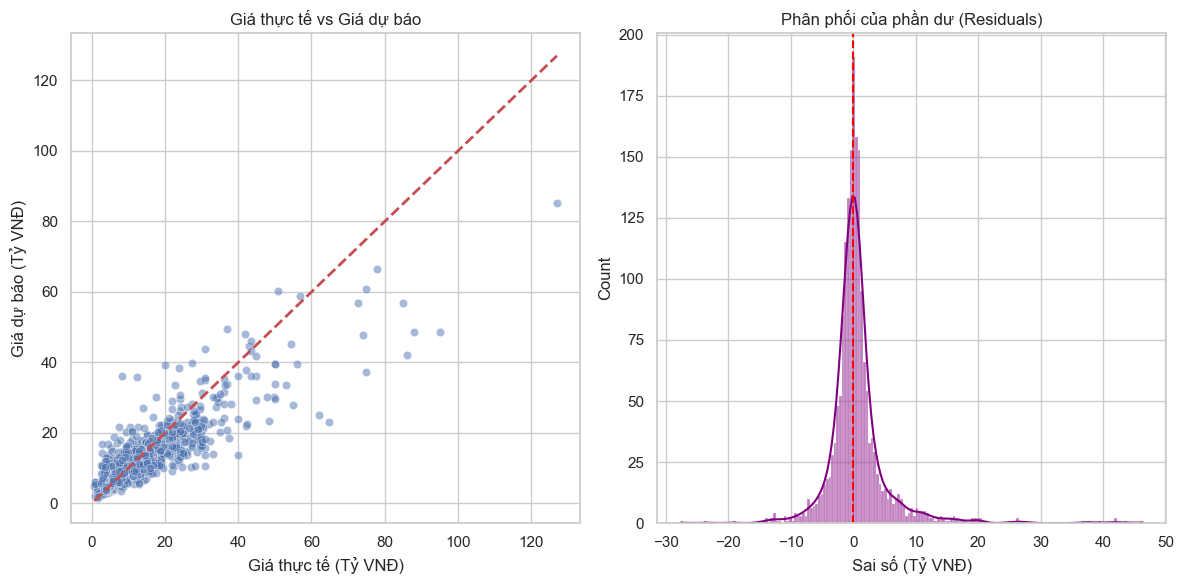

In [37]:
plt.figure(figsize=(12, 6))

# Tính toán phần dư (Residuals)
residuals = y_test_original - y_pred_original

# Vẽ biểu đồ Scatter giữa giá thực tế và giá dự báo
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 
         'r--', lw=2)
plt.title("Giá thực tế vs Giá dự báo")
plt.xlabel("Giá thực tế (Tỷ VNĐ)")
plt.ylabel("Giá dự báo (Tỷ VNĐ)")

# Vẽ biểu đồ phân phối của phần dư
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title("Phân phối của phần dư (Residuals)")
plt.xlabel("Sai số (Tỷ VNĐ)")

plt.tight_layout()
plt.show()



### 1. Phân tích biểu đồ Scatter (Giá thực tế vs Giá dự báo)
*   **Độ khớp ở phân khúc đại trà (0 - 40 tỷ VNĐ):** Các điểm dữ liệu tập trung rất dày và bám sát đường nét đứt màu đỏ ($y=x$). Điều này cho thấy mô hình hoạt động cực kỳ hiệu quả và ổn định đối với các bất động sản thuộc phân khúc phổ thông. Sai số ở vùng này rất thấp, chứng tỏ kỹ thuật **Tương tác không gian** (nhân Diện tích với Quận) đã giúp mô hình "hiểu" được đơn giá đặc thù của từng khu vực địa lý.
*   **Hiện tượng Underestimation (Dự báo thấp hơn thực tế):** Khi giá trị thực tế vượt ngưỡng 60 tỷ VNĐ, các điểm dữ liệu có xu hướng nằm lệch xuống phía dưới đường lý tưởng. Điều này phản ánh giới hạn của mô hình tuyến tính: dù đã có biến diện tích đa thức, nó vẫn chưa bắt kịp biên độ tăng giá phi mã của các bất động sản siêu sang (biệt thự độc bản, vị trí kim cương).
*   **Xử lý Outlier:** Điểm xa nhất bên phải (thực tế ~125 tỷ, dự báo ~85 tỷ) cho thấy một sai số lớn. Tuy nhiên, nhờ bộ lọc **KDE Denoising** ở bước Feature Engineering, các điểm "nhiễu" mật độ thấp đã bị loại bỏ bớt, giúp đường hồi quy không bị kéo lệch quá sâu, giữ cho tổng thể mô hình vẫn đạt $R^2$ cao (0.7509).

### 2. Phân tích biểu đồ Phân phối phần dư (Residuals)
*   **Tính ổn định (Precision):** Cột giá trị tập trung rất cao và nhọn ngay tại vạch số **0**. Điều này chứng minh rằng mô hình có độ tin cậy rất cao; đại đa số các căn nhà đều được định giá với sai số gần như bằng 0. 
*   **Hình dạng phân phối:** Đường cong KDE có dạng hình chuông đối xứng ở vùng lõi, cho thấy sai số ngẫu nhiên tuân theo phân phối chuẩn. Đây là dấu hiệu của một mô hình Hồi quy tuyến tính tốt, không bị hiện tượng thiên lệch (bias) hệ thống ở phân khúc nhà phố thông thường.
*   **Đuôi lệch phải (Positive Skew):** Biểu đồ có phần đuôi kéo dài về phía bên phải (sai số dương). Sai số dương nghĩa là **Giá thực tế > Giá dự báo**. Điều này khớp với quan sát ở biểu đồ scatter: mô hình thường bị "hụt hơi" khi định giá những căn biệt thự đắt tiền nhất.

